In [4]:
import os, sys
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), "src"))

import torch
import matplotlib.pyplot as plt

from discretize_distributions.distributions import MultivariateNormal, MixtureMultivariateNormal, Categorical
from wass_prop import multi_step_empirical, AmbiguityBall, multi_step, SampledPath
from dynamics import DoubleSpiral2dDynamics, AdditiveNoiseDynamics
import plot

# Efficient Uncertainty Propagation with Guarantees in Wasserstein Distance

This notebook provides an illustrative demonstration of our recent works on **probabilistic uncertainty propagation and quantification**. Through a concise example, we highlight the key ideas and connections between the following papers:

1. [Finite Neural Networks as Mixtures of Gaussian Processes: from Provable Error Bounds to Prior Selection](https://arxiv.org/pdf/2407.18707)  
   S. Adams, A. Patané, M. Lahijanian, L. Laurenti — *arXiv:2407.18707 (2024)*
2. [Uncertainty Propagation in Stochastic Systems via Mixture Models with Error Quantification](https://arxiv.org/abs/2403.15626)  
   E. Figueiredo, A. Patané, M. Lahijanian, L. Laurenti — *CDC (2024)*
3. [Efficient Uncertainty Propagation with Guarantees in Wasserstein Distance](https://arxiv.org/pdf/2506.08689)  
   E. Figueiredo, S. Adams, P.M. Esfahani, L. Laurenti — *arXiv:2506.08689 (2025)*
4. [Formal Uncertainty Propagation for Stochastic Dynamical Systems with Additive Noise](https://arxiv.org/pdf/2505.11219)  
   S. Adams, E. Figueiredo, L. Laurenti — *CDC (2025)*

---

**Authors**

- **Main authors:** Eduardo Figueiredo & Steven Adams (PhD candidates, TU Delft)  
- **Supervisor:** Luca Laurenti (TU Delft)  
- **Collaborators:** A. Patané (Trinity College Dublin), M. Lahijanian (University of Colorado), P.M. Esfahani (TU Delft)

---

**Python Packages**

- [**discretize_distributions**](https://github.com/sjladams/discretize_distributions)  
- [**WassProp**](https://github.com/sjladams/WassProp)

---

### Problem Setup

#### System Dynamics
Consider a discrete-time stochastic system:
$$
x_{k+1} = f(x_k) + \omega_k, 
\qquad x_0 \sim \mathbb{P}_0, 
\qquad \omega_k \sim \mathbb{P}_{\omega_k}.
$$

If the initial and noise distributions $\mathbb{P}_0$ and $\mathbb{P}_{\omega_k}$ were known, the distribution of the state at time $k+1$ is given by
$$
\mathbb{P}_{x_{k+1}} = (f\#\mathbb{P}_{x_k}) * \mathbb{P}_{\omega_k},
$$
where $f\#\mathbb{P}_{x_k}$ denotes the **pushforward measure** of $\mathbb{P}_{x_k}$ through $f$.  For nonlinear dynamics $f$, computing $\mathbb{P}_{x_{k+1}}$ exactly is generally **infeasible**.

#### Model Uncertainty
Let $\mathbb{W}_2$ denote the 2-Wasserstein distance, and define the 2-Wasserstein ambiguity set of radius $\theta$ centered at $\bar{\mathbb{P}}$ as
$$
\mathbb{B}_\theta(\bar{\mathbb{P}}) 
= \{\, \mathbb{P} \mid \mathbb{W}_2(\mathbb{P}, \bar{\mathbb{P}}) \le \theta \,\}.
$$

We assume both the initial and noise distributions are uncertain:
$$
\mathbb{P}_0 \in \mathbb{B}_{\theta_x}(\bar{\mathbb{P}}_0),
\qquad 
\mathbb{P}_{\omega_k} \in \mathbb{B}_{\theta_\omega}(\bar{\mathbb{P}}_\omega).
$$
with $\bar{\mathbb{P}}_0$ and $\bar{\mathbb{P}}_\omega$ are Gaussian mixture distributions.

#### Problem Statement

Given a time horizon $K \in \mathbb{N} \cup \{\infty\}$, our goal is to compute sets $\mathbb{S}_{x_0}, \ldots, \mathbb{S}_{x_K}$ defined recursively as
$$
\begin{aligned}
\mathbb{S}_{x_0} 
&= \mathbb{B}_{\theta_x}(\bar{\mathbb{P}}_0), \\[4pt]
\mathbb{S}_{x_{k+1}} 
&= \bigl\{\, (f\#\mathbb{P}_{x_k}) * \mathbb{P}_{\omega_k}
\;\big|\;
\mathbb{P}_{x_k} \in \mathbb{S}_{x_k},\;
\mathbb{P}_{\omega_k} \in \mathbb{B}_{\theta_\omega}(\bar{\mathbb{P}}_\omega)
\,\bigr\},
\quad k < K.
\end{aligned}
$$

Each $\mathbb{S}_{x_k}$ thus represents all possible state distributions at time $k$ consistent with the initial and noise uncertainties.

#### Example: Uncertainty Propagation in Nonlinear Double-Spiral Dynamics with Additive Noise

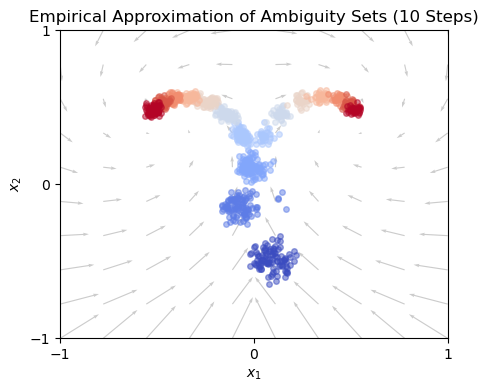

In [2]:
dynamics = AdditiveNoiseDynamics(DoubleSpiral2dDynamics())

p0 = AmbiguityBall(
    center=MultivariateNormal(loc=torch.tensor([0.1, -0.5]), covariance_matrix=torch.eye(2) * 1e-3), 
    radius=0.1
)
noise = AmbiguityBall(
    center=MultivariateNormal(loc=torch.zeros(2), covariance_matrix=torch.eye(2) * 1e-4), 
    radius=0.01
)

true_samples = multi_step_empirical(dynamics=dynamics, p_emp=p0.sample(100), noise=noise, num_time_steps=10)

ax = plot.init_ax( xlim=[-1.0, 1.0], ylim=[-1., 1.0], figsize=(5, 4), title="Empirical Approximation of Ambiguity Sets (10 Steps)")
ax = plot.plot_dynamics(ax, dynamics, scale=None, alpha=0.2)
ax = plot.plot_path(ax, samples=true_samples)

### Approximation Scheme

We approximate the (generally intractable) uncertainty sets $\{\mathbb{S}_{x_k}\}_{k=0}^K$ by **2-Wasserstein ambiguity balls**:
for each $k \le K$, compute a center $\bar{\mathbb{P}}_{x_k}$ and radius $\theta_k$ such that
$$
    \mathbb{B}_{\theta_k}(\bar{\mathbb{P}}_{x_k}) \subseteq \mathbb{S}_{x_k}.
$$

Our construction proceeds in two parts:
1. **Centers** $\bar{\mathbb{P}}_{x_k}$ are chosen as **mixture distributions obtained by quantization**, to keep support compact and computations efficient.
2. **Radii** $\theta_k$ certify a guaranteed 2-Wasserstein over-approximation (computed later in the demo).

<img src="assets/method.png" width="600">

### 1) Centers via Quantization (Mixture Approximation)

Given a set of point $\mathcal{C}=\{c_i\}_{i=1}^N \subset \mathbb{R}^d$, let $\{\mathcal{R}_i\}_{i=1}^N$ be the Voronoi partition of $\mathbb{R}^n$ w.r.t. $\mathcal{C}$. Define the quantization operation
$$
    \Delta_{\mathcal{C}}(x) = \arg\min_{c \in \mathcal{C}} \|x - c\|.
$$
The **quantization** of a probability distribution $\mathbb{P}$ w.r.t. $\mathcal{C}$ is
$$ 
    \Delta_{\mathcal{C}}\#\mathbb{P} = \sum_{i=1}^N \mathbb{P}(\mathcal{R}_i)\,\delta_{c_i}.
$$

We follow [1] (implemented in
[`discretize_distributions`](https://github.com/sjladams/discretize_distributions)) to efficiently construct $\Delta_{\mathcal{C}}\#\mathbb{P}$ that given $N$ minimizes and provides $\mathbb{W}_2\!\left(\mathbb{P}, \Delta_{\mathcal{C}}\#\mathbb{P}\right)$.

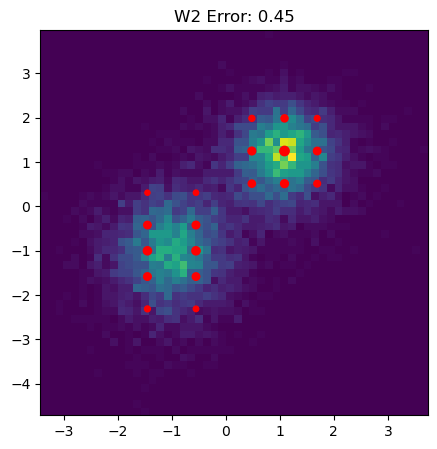

In [6]:
import discretize_distributions as dd

locs = torch.tensor([[1.0, 1.0], [1.1, 1.3], [-1.0, -1.0],[-1.1, -1.3], [-0.9, -0.8]])
covariance_matrices = torch.diag_embed(torch.tensor([[0.5, 0.6],[0.2, 0.3], [0.2, 0.4], [0.4, 0.8], [0.5, 0.6]]))
probs = torch.tensor([0.25, 0.25, 0.1, 0.2, 0.2])

gmm = MixtureMultivariateNormal(Categorical(probs=probs), MultivariateNormal(loc=locs, covariance_matrix=covariance_matrices))

scheme = dd.generate_scheme(gmm, scheme_size=10 * 2)
disc_gmm, w2 = dd.discretize(gmm, scheme)

fig, ax = plt.subplots(figsize=(5, 5))
ax = plot.plot_2d_dist(ax, gmm)
ax = plot.plot_2d_cat_float(ax, disc_gmm)
_ = ax.set_title(f'W2 Error: {w2:.2f}')

**Recursive centers.** 
Using the quantization operator, we define the sequence of center approximations as
$$
\begin{aligned}
    \bar{\mathbb{P}}_{x_1} &= \Delta_{\mathcal{C}_0}\#\bar{\mathbb{P}}_{x_0}, \\[3pt]
    \bar{\mathbb{P}}_{x_{k+1}} &= (f\# \Delta_{\mathcal{C}_k}\#\bar{\mathbb{P}}_{x_k}) * \bar{\mathbb{P}}_\omega,
    \qquad k = 0, \dots, K-1.
\end{aligned}
$$
That is, **quantization is applied before convolution with the noise distribution**, ensuring the propagated centers remain computationally tractable while preserving a mixture-based representation.

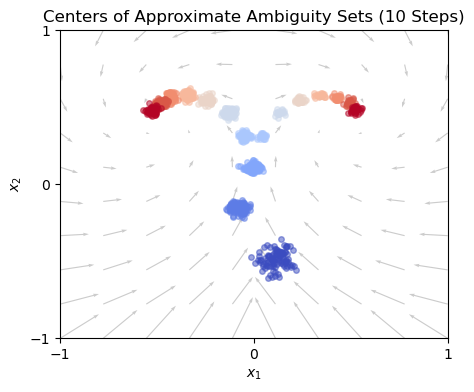

In [4]:
path = multi_step(dynamics=dynamics, q=p0, noise=noise, num_time_steps=10, num_locs=10, print_progress=False)
approx_samples = SampledPath({k: path.at(k).sample(100) for k in path.ordered_indices})

ax = plot.init_ax( xlim=[-1.0, 1.0], ylim=[-1., 1.0], figsize=(5, 4), title="Centers of Approximate Ambiguity Sets (10 Steps)")
ax = plot.plot_dynamics(ax, dynamics, scale=None, alpha=0.2)
ax = plot.plot_path(ax, samples=approx_samples)

### 2) Radii via Wasserstein Error Bounds
**Proposition 2 (from [5])**  
For every $i$, let $\alpha_i$ and $\beta_i$ be such that, for all $x \in \mathbb{R}^d$,
$$
\| f(x) - f(c_i) \|^2 \leq \alpha_i \, \|x - c_i\|^\rho + \beta_i.
$$
Define the **quantization error term**
$$
\theta_\Delta 
= \left(
    \sum_{i=1}^N 
    \int_{\mathcal{R}_i} 
    \|x - c_i\|^\rho \, d\mathbb{P}(x)
\right)^{1/\rho}.
$$

Then, letting $\hat{\alpha} = \max_i \alpha_i$, it holds that
$$
\sup_{\substack{
    \mathbb{P}\in\mathbb{B}_{\theta_k}(\bar{\mathbb{P}}_{x_k}),\\[2pt]
    \mathbb{P}_\omega\in\mathbb{B}_{\theta_\omega}(\bar{\mathbb{P}}_\omega)
}}
\mathbb{W}_2\!\left(
    f\#\mathbb{P} * \mathbb{P}_\omega,\,
    \bar{\mathbb{P}}_{x_{k+1}}
\right)
\leq
\theta_\omega
+ \left(
    \hat{\alpha}(\theta_k + \theta_\Delta)
    + \sum_{i=1}^N \bar{\mathbb{P}}_{x_k}(\mathcal{R}_i)\,\beta_i
\right)^{1/2}.
$$

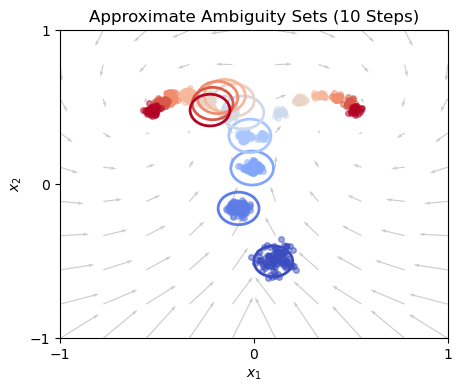

In [5]:
ax = plot.init_ax( xlim=[-1.0, 1.0], ylim=[-1., 1.0], figsize=(5, 4), title="Approximate Ambiguity Sets (10 Steps)")
ax = plot.plot_dynamics(ax, dynamics, scale=None, alpha=0.2)
ax = plot.plot_path(ax, samples=approx_samples, path=path)

<div style="display: flex; justify-content: space-around;">
  <figure style="text-align: center;">
    <img src="assets/wassprop_qr.png" style="width: 200px;">
    <figcaption style="font-size: 16px; margin-top: 6px;">WassProp</figcaption>
  </figure>

  <figure style="text-align: center;">
    <img src="assets/discretize_distributions_qr.png" style="width: 200px;">
    <figcaption style="font-size: 16px; margin-top: 6px;">discretize_distributions</figcaption>
  </figure>
</div>

## Generalization

Our framework generalizes naturally to stochastic systems of the form
$$
x_{k+1} = f(x_k, \omega_k),
\qquad 
x_0 \sim \mathbb{P}_0 \in \mathbb{B}_{\theta_{x_0}}(\bar{\mathbb{P}}_0),
\qquad
\mathbb{P}_\omega \in \mathbb{B}_{\theta_\omega}(\bar{\mathbb{P}}_\omega),
$$
by applying the **quantization operation to both the state and the noise distributions**, as demonstrated in [3].

### Applications to Planning

We are currently extending this framework to **planning under uncertainty**,  where the goal is to compute control actions that are robust with respect to distributional shifts in the dynamics and error models.  

In this context, the ambiguity sets provide a natural tool for:
- guaranteeing safety and goal reachability in stochastic environments, and  
- quantifying the trade-off between robustness and conservatism in planning.

This ongoing work integrates the presented propagation scheme within optimization-based planning frameworks.